In [ ]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip


In [ ]:
import zipfile
import os

with zipfile.ZipFile("/content/images.zip", 'r') as zip_ref:
    zip_ref.extractall("images")

In [ ]:
!pip install torch torchvision faiss-cpu matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 881.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.7/30.7 MB 41.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import faiss
from PIL import Image
import os
import matplotlib.pyplot as plt

# Load pre-trained ResNet50
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # remove classification layer
model.eval()

# Transformation to match ResNet input format
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Folder with your images
image_folder = '/content/images'  # Make sure this is correct

# Function to extract features from an image
def extract_feature(img_path):
    image = Image.open(img_path).convert('RGB')
    image = transform(image).unsqueeze(0)
    with torch.no_grad():
        feature = model(image).squeeze().numpy()
    return feature.flatten()

# Load and process images
image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

features = []
valid_paths = []

for path in image_paths:
    try:
        feat = extract_feature(path)
        features.append(feat)
        valid_paths.append(path)
    except Exception as e:
        print(f"Failed to process {path}: {e}")

features = np.vstack(features).astype('float32')

# Create a FAISS index
index = faiss.IndexFlatL2(features.shape[1])
index.add(features)
def extract_feature(img_path):
    image = Image.open(img_path).convert('RGB')
    image = transform(image).unsqueeze(0)
    with torch.no_grad():
        feature = model(image).squeeze().numpy()
    return feature.flatten()

# Load and process images
image_paths = [os.path.join(image_folder, f) for f in os.listdir(image_folder)
               if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

features = []
valid_paths = []

for path in image_paths:
    try:
        feat = extract_feature(path)
        features.append(feat)
        valid_paths.append(path)
    except Exception as e:
        print(f"Failed to process {path}: {e}")

features = np.vstack(features).astype('float32')

# Create a FAISS index
index = faiss.IndexFlatL2(features.shape[1])
index.add(features)

In [ ]:
uploaded = files.upload()  # test image
query_image = list(uploaded.keys())[0]  # Gets the uploaded file name

Saving Screenshot 2025-04-13 114247.png to Screenshot 2025-04-13 114247.png


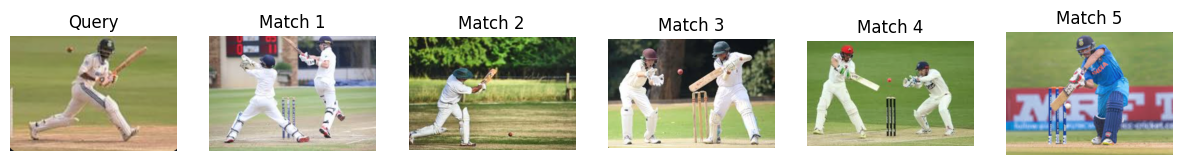

In [ ]:
def search_similar(query_img_path, top_k=5):
    query_feat = extract_feature(query_img_path).reshape(1, -1).astype('float32')
    distances, indices = index.search(query_feat, top_k)
    return [valid_paths[i] for i in indices[0]], distances[0]

def show_results(query_img, results):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, len(results) + 1, 1)
    plt.imshow(Image.open(query_img))
    plt.title("Query")
    plt.axis('off')
    for i, res_path in enumerate(results):
        plt.subplot(1, len(results) + 1, i + 2)
        plt.imshow(Image.open(res_path))
        plt.title(f"Match {i+1}")
        plt.axis('off')
    plt.show()

results, _ = search_similar(query_image, top_k=5)
show_results(query_image, results)